Installations

In [1]:
!pip install -q google-genai shap sentence-transformers faiss-cpu

Import Statements

In [2]:
import zipfile
import os
import matplotlib.pyplot as plt
import pandas as pd
import re
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [4]:
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [5]:
import json
import numpy as np
import shap
import faiss

from google import genai
from sentence_transformers import SentenceTransformer

Loading the dataset

In [6]:
zip_path = "/content/archive (6).zip"
extract_path = "/content/project_files"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped to:", extract_path)
print(os.listdir(extract_path))

Unzipped to: /content/project_files
['train.csv', 'test.csv', 'sample_submission.csv']


In [7]:
for root, dirs, files in os.walk("/content/project_files"):
    for file in files:
        if file.endswith((".ipynb", ".py", ".csv")):
            print(os.path.join(root, file))

/content/project_files/train.csv
/content/project_files/test.csv
/content/project_files/sample_submission.csv


In [8]:
# Load the dataset and inspect basic structure
df = pd.read_csv('/content/project_files/train.csv')
df.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   policy_tenure                     58592 non-null  float64
 2   age_of_car                        58592 non-null  float64
 3   age_of_policyholder               58592 non-null  float64
 4   area_cluster                      58592 non-null  object 
 5   population_density                58592 non-null  int64  
 6   make                              58592 non-null  int64  
 7   segment                           58592 non-null  object 
 8   model                             58592 non-null  object 
 9   fuel_type                         58592 non-null  object 
 10  max_torque                        58592 non-null  object 
 11  max_power                         58592 non-null  object 
 12  engi

In [10]:
print("Shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution:\n", df["is_claim"].value_counts())
print("\nTarget proportion:\n", df["is_claim"].value_counts(normalize=True))

Shape: (58592, 44)

Missing values: 0

Duplicate rows: 0

Target distribution:
 is_claim
0    54844
1     3748
Name: count, dtype: int64

Target proportion:
 is_claim
0    0.936032
1    0.063968
Name: proportion, dtype: float64


In [11]:
df = df.drop(columns=["policy_id"]) #policy_id is just an identifier

Separating Feature Types

In [12]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumeric columns:", numeric_cols)

Categorical columns: ['area_cluster', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'transmission_type', 'steering_type', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']

Numeric columns: ['policy_tenure', 'age_of_car', 'age_of_policyholder', 'population_density', 'make', 'airbags', 'displacement', 'cylinder', 'gear_box', 'turning_radius', 'length', 'width', 'height', 'gross_weight', 'ncap_rating', 'is_claim']


Removing Target Column

In [13]:
target_col = "is_claim"
numeric_cols.remove(target_col)

print("Updated numeric columns:", numeric_cols)

Updated numeric columns: ['policy_tenure', 'age_of_car', 'age_of_policyholder', 'population_density', 'make', 'airbags', 'displacement', 'cylinder', 'gear_box', 'turning_radius', 'length', 'width', 'height', 'gross_weight', 'ncap_rating']


Inspecting Categorical Columns

In [14]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


area_cluster
area_cluster
C8     13654
C2      7342
C5      6979
C3      6101
C14     3660
C13     3423
C10     3155
C9      2734
C7      2167
C12     1589
Name: count, dtype: int64

segment
segment
B2         18314
A          17321
C2         14018
B1          4173
C1          3557
Utility     1209
Name: count, dtype: int64

model
model
M1     14948
M4     14018
M6     13776
M8      4173
M7      2940
M3      2373
M9      2114
M5      1598
M10     1209
M2      1080
Name: count, dtype: int64

fuel_type
fuel_type
Petrol    20532
CNG       20330
Diesel    17730
Name: count, dtype: int64

max_torque
max_torque
113Nm@4400rpm     17796
60Nm@3500rpm      14948
250Nm@2750rpm     14018
82.1Nm@3400rpm     4173
91Nm@4250rpm       2373
200Nm@1750rpm      2114
200Nm@3000rpm      1598
85Nm@3000rpm       1209
170Nm@4000rpm       363
Name: count, dtype: int64

max_power
max_power
88.50bhp@6000rpm     17796
40.36bhp@6000rpm     14948
113.45bhp@4000rpm    14018
55.92bhp@5300rpm      4173
67.06bhp@5500r

Dropping unimportant columns

In [15]:
df = df.drop(columns=['is_speed_alert'])
df = df.drop(columns=['is_central_locking', 'is_rear_window_washer'])

Taking Binary Columns Into Account

In [16]:
binary_cols = [
    'is_esc', 'is_adjustable_steering', 'is_tpms',
    'is_parking_sensors', 'is_parking_camera',
    'is_front_fog_lights', 'is_rear_window_wiper',
    'is_rear_window_defogger', 'is_brake_assist',
    'is_power_door_locks', 'is_power_steering',
    'is_driver_seat_height_adjustable',
    'is_day_night_rear_view_mirror', 'is_ecw'
]

In [17]:
df['is_esc'].unique()

array(['No', 'Yes'], dtype=object)

In [18]:
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [19]:
df[binary_cols].isnull().sum()

,0
is_esc,0
is_adjustable_steering,0
is_tpms,0
is_parking_sensors,0
is_parking_camera,0
is_front_fog_lights,0
is_rear_window_wiper,0
is_rear_window_defogger,0
is_brake_assist,0
is_power_door_locks,0


In [20]:
print(df["max_torque"].head(10).tolist())
print(df["max_power"].head(10).tolist())

['60Nm@3500rpm', '60Nm@3500rpm', '60Nm@3500rpm', '113Nm@4400rpm', '91Nm@4250rpm', '250Nm@2750rpm', '200Nm@3000rpm', '113Nm@4400rpm', '250Nm@2750rpm', '113Nm@4400rpm']
['40.36bhp@6000rpm', '40.36bhp@6000rpm', '40.36bhp@6000rpm', '88.50bhp@6000rpm', '67.06bhp@5500rpm', '113.45bhp@4000rpm', '88.77bhp@4000rpm', '88.50bhp@6000rpm', '113.45bhp@4000rpm', '88.50bhp@6000rpm']


Fixing max_torque and max_power

In [21]:
# Torque extraction
df['torque'] = df['max_torque'].apply(lambda x: float(re.findall(r'\d+\.?\d*', x)[0]))
df['torque_rpm'] = df['max_torque'].apply(lambda x: float(re.findall(r'\d+\.?\d*', x)[1]))

# Power extraction
df['power'] = df['max_power'].apply(lambda x: float(re.findall(r'\d+\.?\d*', x)[0]))
df['power_rpm'] = df['max_power'].apply(lambda x: float(re.findall(r'\d+\.?\d*', x)[1]))

In [22]:
df = df.drop(columns=['max_torque', 'max_power'])

Checking the DataFrame

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 42 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_tenure                     58592 non-null  float64
 1   age_of_car                        58592 non-null  float64
 2   age_of_policyholder               58592 non-null  float64
 3   area_cluster                      58592 non-null  object 
 4   population_density                58592 non-null  int64  
 5   make                              58592 non-null  int64  
 6   segment                           58592 non-null  object 
 7   model                             58592 non-null  object 
 8   fuel_type                         58592 non-null  object 
 9   engine_type                       58592 non-null  object 
 10  airbags                           58592 non-null  int64  
 11  is_esc                            58592 non-null  int64  
 12  is_a

True Categorical Columns (Will Focus on OneHotEncoding Later)

In [24]:
categorical_cols = [
    'area_cluster', 'segment', 'model',
    'fuel_type', 'engine_type',
    'rear_brakes_type', 'transmission_type',
    'steering_type'
]

# **Visualisations**

Target Distribution

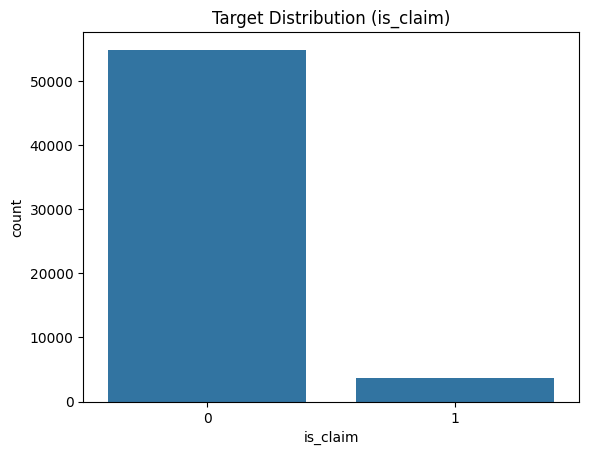

is_claim
0    0.936032
1    0.063968
Name: proportion, dtype: float64


In [25]:
sns.countplot(x='is_claim', data=df)
plt.title("Target Distribution (is_claim)")
plt.show()

print(df['is_claim'].value_counts(normalize=True))

The dataset is highly imbalanced, with a majority of non-claim instances.

Numerical Distribution

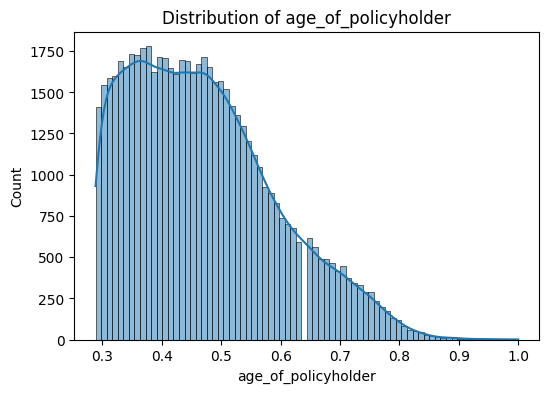

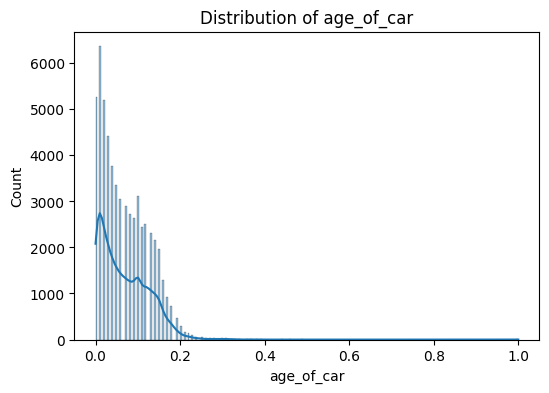

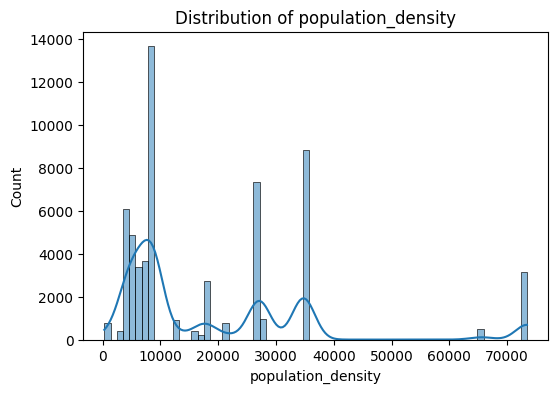

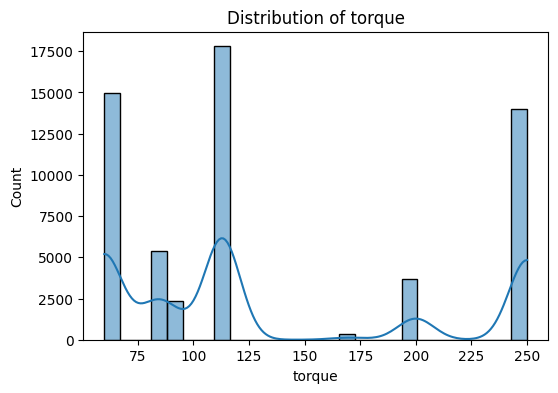

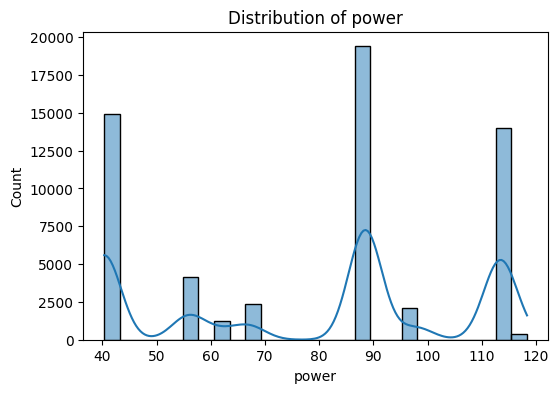

In [26]:
num_cols_to_plot = [
    'age_of_policyholder',
    'age_of_car',
    'population_density',
    'torque',
    'power'
]

for col in num_cols_to_plot:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

The distribution of policyholder age shows a concentration in the middle-age range, indicating that the dataset is dominated by moderately experienced drivers.

The distribution of vehicle age is heavily skewed towards newer vehicles, suggesting that older vehicles are underrepresented in the dataset.

Population density exhibits a multi-modal distribution, indicating the presence of distinct geographic clusters rather than a uniform spread.

Torque values appear in discrete clusters, reflecting specific vehicle configurations rather than a continuous distribution.

Power values also exhibit clustered distributions, indicating that they are determined by predefined engine configurations across vehicle models.

**From torque + power:**

These features are not continuous in nature but represent discrete configurations tied to specific vehicle models, suggesting potential multicollinearity among vehicle specification features.

# **Feature vs Target**

Age vs claim

/tmp/ipykernel_9793/1919713833.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_claim = df.groupby('age_bin')['is_claim'].mean()


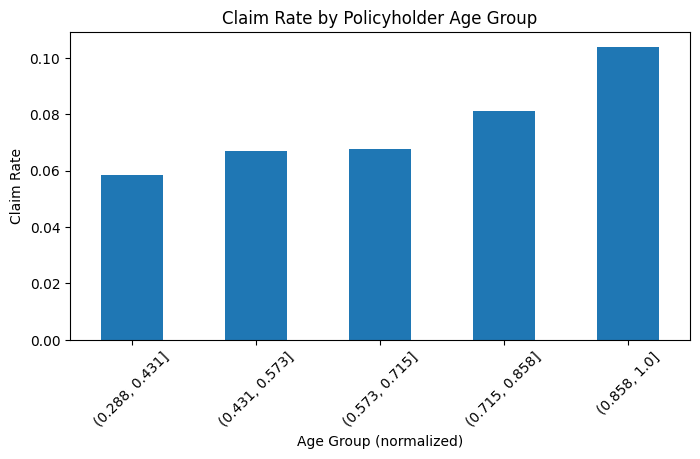

In [27]:
df['age_bin'] = pd.cut(df['age_of_policyholder'], bins=5)
age_claim = df.groupby('age_bin')['is_claim'].mean()
age_claim.plot(kind='bar', figsize=(8,4))
plt.title("Claim Rate by Policyholder Age Group")
plt.xlabel("Age Group (normalized)")
plt.ylabel("Claim Rate")
plt.xticks(rotation=45)
plt.show()

Claim probability increases consistently across policyholder age groups, indicating that age is a meaningful predictor of insurance risk, with older individuals exhibiting higher likelihood of filing claims.

Car age vs claim

/tmp/ipykernel_9793/2470012600.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  car_age_claim = df.groupby('car_age_bin')['is_claim'].mean()


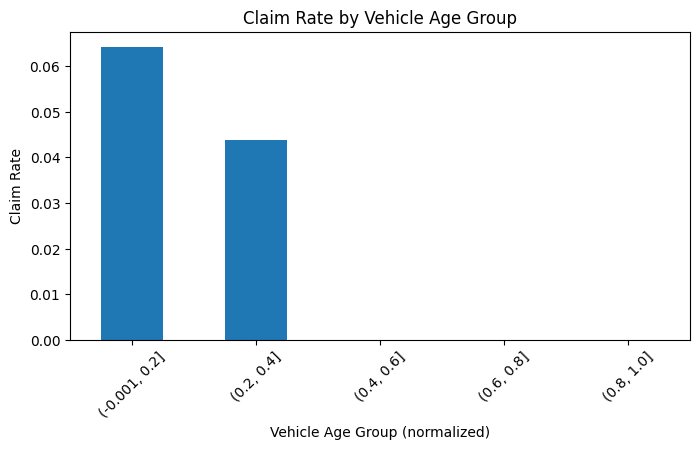

In [28]:
df['car_age_bin'] = pd.cut(df['age_of_car'], bins=5)
car_age_claim = df.groupby('car_age_bin')['is_claim'].mean()
car_age_claim.plot(kind='bar', figsize=(8,4))
plt.title("Claim Rate by Vehicle Age Group")
plt.xlabel("Vehicle Age Group (normalized)")
plt.ylabel("Claim Rate")
plt.xticks(rotation=45)
plt.show()

Claim rates appear higher for newer vehicles, but the lack of data in older vehicle categories limits reliable conclusions, indicating potential dataset imbalance in vehicle age distribution.

Torque/Power vs claim

/tmp/ipykernel_9793/454046876.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  torque_claim = df.groupby('torque_bin')['is_claim'].mean()


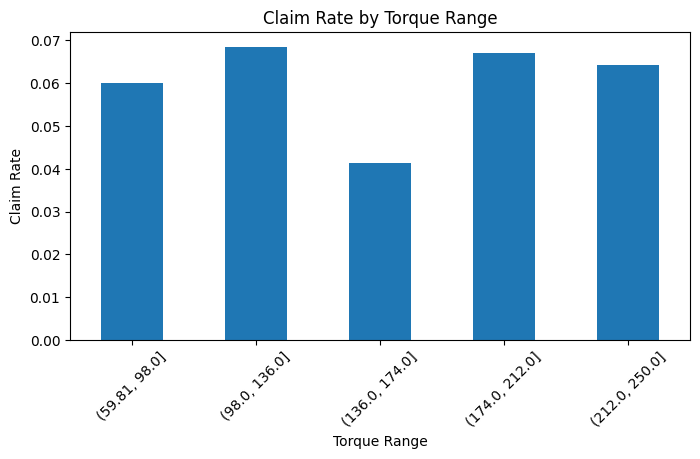

In [29]:
df['torque_bin'] = pd.cut(df['torque'], bins=5)
torque_claim = df.groupby('torque_bin')['is_claim'].mean()
torque_claim.plot(kind='bar', figsize=(8,4))
plt.title("Claim Rate by Torque Range")
plt.xlabel("Torque Range")
plt.ylabel("Claim Rate")
plt.xticks(rotation=45)
plt.show()

Torque shows non-linear variation with claim rates, with certain mid-range values exhibiting lower risk, suggesting a complex relationship rather than a straightforward trend.

/tmp/ipykernel_9793/2755996474.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  power_claim = df.groupby('power_bin')['is_claim'].mean()


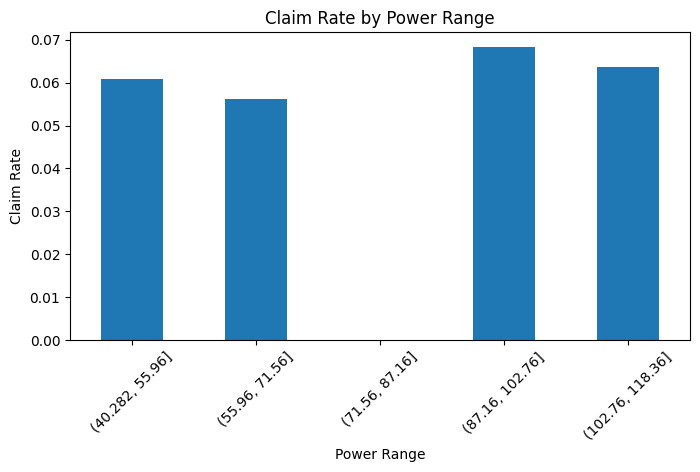

In [30]:
df['power_bin'] = pd.cut(df['power'], bins=5)
power_claim = df.groupby('power_bin')['is_claim'].mean()
power_claim.plot(kind='bar', figsize=(8,4))
plt.title("Claim Rate by Power Range")
plt.xlabel("Power Range")
plt.ylabel("Claim Rate")
plt.xticks(rotation=45)
plt.show()

Claim rates vary slightly across power ranges, but no strong or consistent pattern is observed, indicating that engine power alone is not a dominant predictor of insurance claims.

# **Categorical vs Target**

Fuel Type

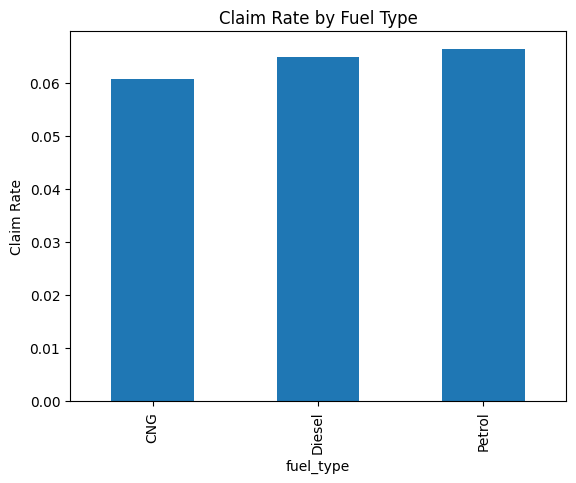

In [31]:
fuel_claim = df.groupby('fuel_type')['is_claim'].mean().sort_values()

fuel_claim.plot(kind='bar')
plt.title("Claim Rate by Fuel Type")
plt.ylabel("Claim Rate")
plt.show()

Fuel type shows minor variation in claim rates, with petrol vehicles exhibiting slightly higher claim probability compared to diesel and CNG vehicles, though the difference is relatively small.

Segment

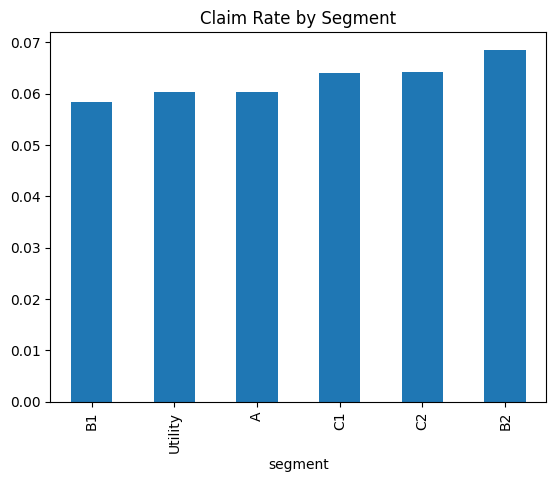

In [32]:
segment_claim = df.groupby('segment')['is_claim'].mean().sort_values()

segment_claim.plot(kind='bar')
plt.title("Claim Rate by Segment")
plt.show()

Vehicle segment demonstrates noticeable variation in claim rates, indicating that different vehicle categories may be associated with varying levels of risk.

Transmission

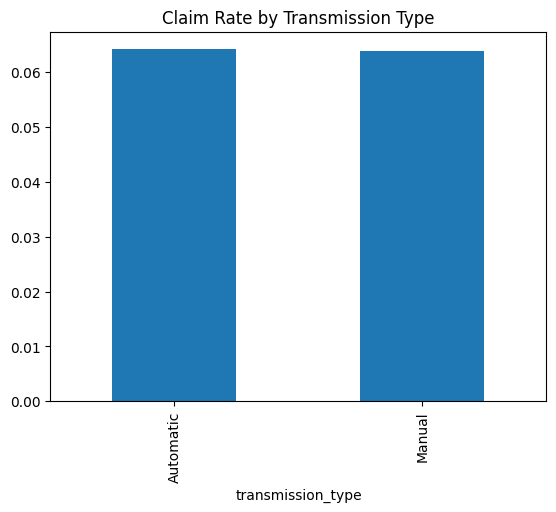

In [33]:
trans_claim = df.groupby('transmission_type')['is_claim'].mean()

trans_claim.plot(kind='bar')
plt.title("Claim Rate by Transmission Type")
plt.show()

Transmission type shows negligible difference in claim rates, suggesting limited predictive value as an independent feature.

Safety Feature Aggregation

In [34]:
safety_cols = [
    'airbags', 'is_esc', 'is_tpms', 'is_brake_assist'
]

df['safety_score'] = df[safety_cols].sum(axis=1)

/tmp/ipykernel_9793/1263511320.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  safety_claim = df.groupby('safety_bin')['is_claim'].mean()


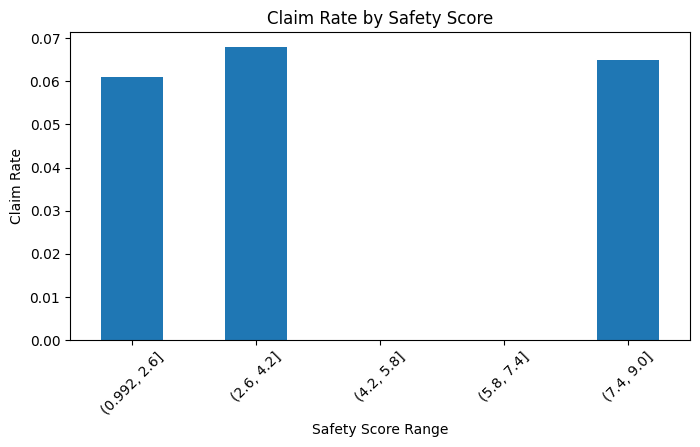

In [35]:
df['safety_bin'] = pd.cut(df['safety_score'], bins=5)
safety_claim = df.groupby('safety_bin')['is_claim'].mean()
safety_claim.plot(kind='bar', figsize=(8,4))
plt.title("Claim Rate by Safety Score")
plt.xlabel("Safety Score Range")
plt.ylabel("Claim Rate")
plt.xticks(rotation=45)
plt.show()

Safety score does not exhibit a consistent relationship with claim probability, suggesting that the impact of safety features may depend on interactions with other variables rather than acting independently.

# **Correlation Matrix for Numerical Cols**

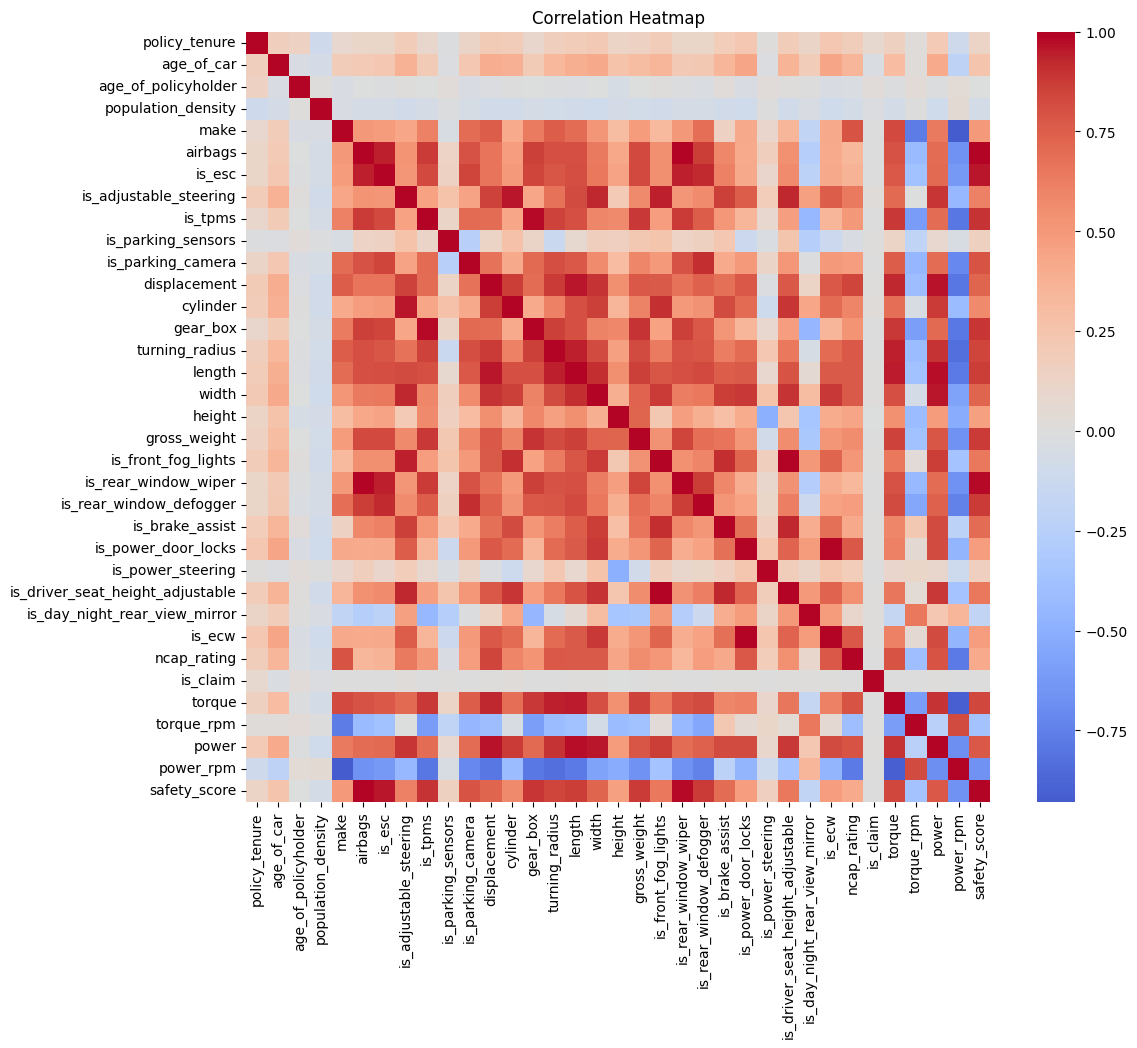

In [36]:
plt.figure(figsize=(12,10))
corr = corr = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

Several vehicle specification features, including displacement, power, torque, vehicle dimensions, and the engineered safety score, show strong positive correlations with each other. This indicates the presence of multicollinearity and redundancy, as these variables are likely capturing overlapping aspects of vehicle design and class.

The target variable does not exhibit strong linear correlation with any individual feature, including the aggregated safety score, suggesting that claim prediction depends on complex, non-linear interactions between multiple variables rather than any single dominant factor.

# **Exploratory Data Analysis Summary**

The dataset consists of structured insurance policy data with a mix of numerical, categorical, and binary variables. Initial analysis revealed that the target variable (is_claim) is highly imbalanced, with the majority of observations corresponding to non-claim cases.

Univariate analysis showed that most policyholders fall within a middle-age range, and the majority of insured vehicles are relatively new. Several numerical features, such as torque and power, exhibit discrete clustered distributions, reflecting predefined vehicle configurations rather than continuous variation.

Bivariate analysis indicated that most individual features, including torque, power, vehicle age, and safety-related variables, do not strongly differentiate between claim and non-claim cases. However, policyholder age demonstrated a clear increasing trend in claim probability, making it one of the few features with a meaningful and consistent relationship with the target variable.

Categorical variables such as vehicle segment showed moderate variation in claim rates, suggesting that certain vehicle categories may be associated with different risk levels. In contrast, features like transmission type exhibited negligible differences, indicating limited standalone predictive value.

Correlation analysis revealed strong positive relationships among vehicle specification features, including displacement, power, torque, vehicle dimensions, and the engineered safety score. This indicates significant multicollinearity and redundancy, as these variables capture overlapping aspects of vehicle characteristics. The safety score, while highly correlated with both safety features and vehicle specifications, does not show a strong relationship with claim probability, suggesting that safety features alone do not independently determine risk.

Overall, the target variable does not exhibit strong linear correlation with any single feature. This suggests that insurance claim prediction is driven by complex, non-linear interactions among multiple variables rather than any single dominant factor. These findings motivate the use of machine learning models capable of capturing such interactions, rather than relying solely on linear relationships.

*Please note: Categorical variables were not encoded during exploratory analysis to preserve interpretability. Encoding will be performed later as part of the machine learning pipeline.*

# **Modeling and Experimental Setup**

**Basic Setup**

In [37]:
# Creating modeling copy from EDA dataframe to avoid chaos
model_df = df.copy()

Checking for bin columns

In [38]:
for col in model_df.columns:
    print(col, model_df[col].dtype)

policy_tenure float64
age_of_car float64
age_of_policyholder float64
area_cluster object
population_density int64
make int64
segment object
model object
fuel_type object
engine_type object
airbags int64
is_esc int64
is_adjustable_steering int64
is_tpms int64
is_parking_sensors int64
is_parking_camera int64
rear_brakes_type object
displacement int64
cylinder int64
transmission_type object
gear_box int64
steering_type object
turning_radius float64
length int64
width int64
height int64
gross_weight int64
is_front_fog_lights int64
is_rear_window_wiper int64
is_rear_window_defogger int64
is_brake_assist int64
is_power_door_locks int64
is_power_steering int64
is_driver_seat_height_adjustable int64
is_day_night_rear_view_mirror int64
is_ecw int64
ncap_rating int64
is_claim int64
torque float64
torque_rpm float64
power float64
power_rpm float64
age_bin category
car_age_bin category
torque_bin category
power_bin category
safety_score int64
safety_bin category


**Data Cleaning for Modeling**

In [39]:
interval_cols = [col for col in model_df.columns if str(model_df[col].dtype) == "interval"]
print("Interval columns:", interval_cols)

Interval columns: []


In [40]:
print(model_df.select_dtypes(include=["category"]).dtypes)

age_bin        category
car_age_bin    category
torque_bin     category
power_bin      category
safety_bin     category
dtype: object


In [41]:
# Dropping EDA bin columns
bin_cols = [
    "age_bin",
    "car_age_bin",
    "torque_bin",
    "power_bin",
    "safety_bin"
]

model_df = model_df.drop(columns=bin_cols)

In [42]:
# Features and target
X = model_df.drop(columns=["is_claim"])
y = model_df["is_claim"]

EDA-derived binning features were removed to avoid redundancy and ensure model training uses raw, information-rich variables only.

The objective of this section is to build and evaluate machine learning models for predicting insurance claim likelihood using structured tabular data.

**Train-Test-Split**

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

The dataset was split using stratified sampling to preserve the original class imbalance distribution between claim and non-claim instances.

**Feature Type Identification**

In [44]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

**Feature Engineering & Preprocessing Pipeline**

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

Categorical variables were encoded using OneHotEncoder while numerical features were standardized, ensuring compatibility across both linear and nonlinear models.

**Logistic Regression Pipeline**

In [46]:
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("=== Logistic Regression ===")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

=== Logistic Regression ===
[[6265 4704]
 [ 339  411]]
              precision    recall  f1-score   support

           0       0.95      0.57      0.71     10969
           1       0.08      0.55      0.14       750

    accuracy                           0.57     11719
   macro avg       0.51      0.56      0.43     11719
weighted avg       0.89      0.57      0.68     11719

ROC-AUC: 0.5861992889050962


Logistic Regression with class balancing was used as a baseline to establish linear separability and assess initial performance under class imbalance.

The model achieved moderate recall for the minority class but suffered from low precision, indicating overprediction of claims due to class imbalance.

**Random Forest (Tree-Based Model)**

In [47]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

# Default predictions (0.5 threshold)
y_pred_rf_default = rf_pipeline.predict(X_test)

print("\n=== Random Forest (Default 0.5 Threshold) ===")
print(confusion_matrix(y_test, y_pred_rf_default))
print(classification_report(y_test, y_pred_rf_default))

y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Custom threshold (try 0.2)
threshold = 0.2
y_pred_rf_custom = (y_prob_rf > threshold).astype(int)

print(f"\n=== Random Forest (Threshold = {threshold}) ===")
print(confusion_matrix(y_test, y_pred_rf_custom))
print(classification_report(y_test, y_pred_rf_custom))

# Evaluation
# print("\n=== Random Forest ===")
# print(confusion_matrix(y_test, y_pred_rf))
# print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


=== Random Forest (Default 0.5 Threshold) ===
[[7130 3839]
 [ 327  423]]
              precision    recall  f1-score   support

           0       0.96      0.65      0.77     10969
           1       0.10      0.56      0.17       750

    accuracy                           0.64     11719
   macro avg       0.53      0.61      0.47     11719
weighted avg       0.90      0.64      0.74     11719


=== Random Forest (Threshold = 0.2) ===
[[   46 10923]
 [    3   747]]
              precision    recall  f1-score   support

           0       0.94      0.00      0.01     10969
           1       0.06      1.00      0.12       750

    accuracy                           0.07     11719
   macro avg       0.50      0.50      0.06     11719
weighted avg       0.88      0.07      0.02     11719

ROC-AUC: 0.647972103199927


Random Forest was implemented to capture nonlinear feature interactions and improve performance on structured tabular data, with class imbalance handled via balanced subsampling.

Random Forest improved overall stability and captured nonlinear patterns, but still required threshold tuning to balance sensitivity and false positives.

**Threshold Tuning**

In [48]:
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [49]:
for t in [0.5, 0.4, 0.3, 0.25]:
    y_pred = (y_prob_rf > t).astype(int)
    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Threshold: 0.5
[[7130 3839]
 [ 327  423]]
              precision    recall  f1-score   support

           0       0.96      0.65      0.77     10969
           1       0.10      0.56      0.17       750

    accuracy                           0.64     11719
   macro avg       0.53      0.61      0.47     11719
weighted avg       0.90      0.64      0.74     11719


Threshold: 0.4
[[4173 6796]
 [ 132  618]]
              precision    recall  f1-score   support

           0       0.97      0.38      0.55     10969
           1       0.08      0.82      0.15       750

    accuracy                           0.41     11719
   macro avg       0.53      0.60      0.35     11719
weighted avg       0.91      0.41      0.52     11719


Threshold: 0.3
[[  882 10087]
 [   25   725]]
              precision    recall  f1-score   support

           0       0.97      0.08      0.15     10969
           1       0.07      0.97      0.13       750

    accuracy                           0.14     1

Different probability thresholds were evaluated to balance recall and precision, highlighting the tradeoff between detecting claims and minimizing false positives.

Lowering the classification threshold increased recall for claim detection but significantly increased false positives, highlighting the tradeoff between sensitivity and precision.

**XGBoost (Boosting Model)**

In [50]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("\n=== XGBoost ===")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:17:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost ===
[[7681 3288]
 [ 413  337]]
              precision    recall  f1-score   support

           0       0.95      0.70      0.81     10969
           1       0.09      0.45      0.15       750

    accuracy                           0.68     11719
   macro avg       0.52      0.57      0.48     11719
weighted avg       0.89      0.68      0.76     11719

ROC-AUC: 0.6171996231804783


XGBoost provided comparable performance to Random Forest but did not significantly outperform it, suggesting limited nonlinear signal in the dataset.

**MLP (Neural Network Model)**

In [51]:
mlp_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=100,
        random_state=42
    ))
])

mlp_pipeline.fit(X_train, y_train)

y_pred_mlp = mlp_pipeline.predict(X_test)
y_prob_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]

print("\n=== MLP ===")
print(confusion_matrix(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_mlp))


=== MLP ===
[[10966     3]
 [  750     0]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10969
           1       0.00      0.00      0.00       750

    accuracy                           0.94     11719
   macro avg       0.47      0.50      0.48     11719
weighted avg       0.88      0.94      0.90     11719

ROC-AUC: 0.6148842495517671


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


The MLP model failed to capture minority class patterns, predicting almost all instances as non-claims, highlighting the limitations of neural networks on imbalanced tabular data.

**Model Comparison Summary**

Tree-based models outperformed linear and neural approaches due to their ability to handle tabular data and class imbalance more effectively.

**Hyperparameter Tuning (Random Forest Optimization)**

In [52]:
rf = RandomForestClassifier(
    class_weight="balanced_subsample",
    random_state=42
)

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", "log2"]
}

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf)
])

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=10,  # keep small for speed
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

print("Best Parameters:", rf_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 10}


Hyperparameter tuning stabilized model behavior but did not significantly improve predictive performance, indicating that the model had already captured most of the available signal.

**Tuned Random Forest**

In [53]:
best_rf = rf_search.best_estimator_

y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf = best_rf.predict(X_test)

print("\n=== Tuned Random Forest ===")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


=== Tuned Random Forest ===
[[7130 3839]
 [ 327  423]]
              precision    recall  f1-score   support

           0       0.96      0.65      0.77     10969
           1       0.10      0.56      0.17       750

    accuracy                           0.64     11719
   macro avg       0.53      0.61      0.47     11719
weighted avg       0.90      0.64      0.74     11719

ROC-AUC: 0.647972103199927


In [54]:
for t in [0.5, 0.4, 0.3]:
    y_pred = (y_prob_rf > t).astype(int)
    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Threshold: 0.5
[[7130 3839]
 [ 327  423]]
              precision    recall  f1-score   support

           0       0.96      0.65      0.77     10969
           1       0.10      0.56      0.17       750

    accuracy                           0.64     11719
   macro avg       0.53      0.61      0.47     11719
weighted avg       0.90      0.64      0.74     11719


Threshold: 0.4
[[4173 6796]
 [ 132  618]]
              precision    recall  f1-score   support

           0       0.97      0.38      0.55     10969
           1       0.08      0.82      0.15       750

    accuracy                           0.41     11719
   macro avg       0.53      0.60      0.35     11719
weighted avg       0.91      0.41      0.52     11719


Threshold: 0.3
[[  882 10087]
 [   25   725]]
              precision    recall  f1-score   support

           0       0.97      0.08      0.15     10969
           1       0.07      0.97      0.13       750

    accuracy                           0.14     1

The tuned Random Forest maintained consistent performance with improved stability, reinforcing it as the most reliable model for this task.

**Handling Class Imbalance (SMOTE)**

In [55]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight=None,  # REMOVE this when using SMOTE
    random_state=42
)

smote_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", rf)
])

smote_pipeline.fit(X_train, y_train)

y_prob_rf = smote_pipeline.predict_proba(X_test)[:, 1]
y_pred_rf = smote_pipeline.predict(X_test)

print("\n=== RF + SMOTE ===")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


=== RF + SMOTE ===
[[7095 3874]
 [ 334  416]]
              precision    recall  f1-score   support

           0       0.96      0.65      0.77     10969
           1       0.10      0.55      0.17       750

    accuracy                           0.64     11719
   macro avg       0.53      0.60      0.47     11719
weighted avg       0.90      0.64      0.73     11719

ROC-AUC: 0.6391143525693621


SMOTE did not improve performance and slightly reduced ROC-AUC, suggesting that synthetic samples introduced noise rather than meaningful patterns.

**Feature Importance Analysis**

In [56]:
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf.named_steps["model"].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(feat_imp.head(15))

num__policy_tenure          0.354454
num__age_of_car             0.225730
num__age_of_policyholder    0.150044
num__population_density     0.034473
cat__area_cluster_C10       0.009510
cat__area_cluster_C3        0.007975
num__height                 0.007746
cat__area_cluster_C7        0.007592
cat__area_cluster_C8        0.007504
num__gross_weight           0.007152
num__width                  0.006777
num__displacement           0.006757
num__length                 0.006488
cat__area_cluster_C14       0.006339
cat__area_cluster_C9        0.005903
dtype: float64


Risk prediction is primarily driven by policy tenure and age-related features, while vehicle specifications and regional attributes contribute marginally.

**Final Model Selection**

The tuned Random Forest model was selected as the final model due to its balanced performance, robustness, and ability to handle class imbalance effectively.

# **LLM Integration Layer for Insurance Risk Explanation and Policy Recommendation**

Configuring Gemini API

**Note on API Usage and Reproducibility**

The LLM-based explanation component uses an external API (Gemini). Due to API usage limits and cost constraints, the outputs shown below are from a successful prior run.

The code is fully functional and can be executed with a valid API key, but re-running it may incur API usage. Therefore, outputs are preserved for evaluation purposes.

The API key has been removed for security reasons.

Please feel free to use your own API key which you can get from Google AI Studio: https://aistudio.google.com/

In [57]:
os.environ["GEMINI_API_KEY"] = "YOUR_API_KEY_HERE"

client = genai.Client()

print("Gemini client initialized successfully.")

Gemini client initialized successfully.


**Part 1: Policy Knowledge Base**

Policy Documents

In [58]:
policy_docs = [
    {
        "title": "Basic Coverage Plan",
        "text": """
        The Basic Coverage Plan is intended for low-risk customers.
        It provides essential coverage for standard accidental damage and basic third-party liability.
        It has the lowest coverage breadth and is suitable for customers with relatively low predicted claim risk.
        It may exclude advanced add-ons, premium roadside support, and enhanced claim handling.
        """
    },
    {
        "title": "Standard Coverage Plan",
        "text": """
        The Standard Coverage Plan is intended for medium-risk customers.
        It includes broader protection than the Basic plan, stronger accidental damage coverage,
        selected add-on benefits, and improved support during claims.
        It is recommended when the customer's predicted risk is moderate and a balanced plan is appropriate.
        """
    },
    {
        "title": "Premium Coverage Plan",
        "text": """
        The Premium Coverage Plan is intended for high-risk customers or customers who want broader protection.
        It includes the most comprehensive coverage, wider support features, and stronger protection options.
        This plan may be paired with a higher deductible recommendation depending on the customer's overall risk profile.
        """
    },
    {
        "title": "Risk Tier Mapping Rules",
        "text": """
        Risk scores are mapped into risk tiers using transparent thresholds.

        Low Risk: 0.00 to 0.30
        Medium Risk: 0.30 to 0.65
        High Risk: 0.65 to 1.00

        Policy recommendation rules:
        Low Risk -> Basic Coverage Plan
        Medium Risk -> Standard Coverage Plan
        High Risk -> Premium Coverage Plan
        """
    },
    {
        "title": "Assistant Scope Boundaries",
        "text": """
        The assistant may explain risk tiers, policy recommendations, top contributing features,
        and general differences between policy plans.

        The assistant must not provide legal advice, official underwriting decisions,
        guaranteed premium quotes, or medical advice.

        If a user asks for exact pricing or legal interpretation, the assistant should clearly say that the request is outside scope.
        """
    }
]

doc_texts = [doc["title"] + "\n" + doc["text"] for doc in policy_docs]

print(f"Loaded {len(doc_texts)} policy documents.")

Loaded 5 policy documents.


**Part 2: Retrieval Layer**

Embedding Model and FAISS Index

In [59]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

doc_embeddings = embedder.encode(doc_texts, convert_to_numpy=True).astype("float32")
dimension = doc_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(doc_embeddings)

print(f"Indexed {len(doc_texts)} policy documents successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Indexed 5 policy documents successfully.


Policy Retrieval Funtion

In [60]:
def retrieve_policy_context(user_query, top_k=3):
    query_embedding = embedder.encode([user_query], convert_to_numpy=True).astype("float32")
    distances, indices = index.search(query_embedding, top_k)

    retrieved_docs = []
    for idx in indices[0]:
        retrieved_docs.append(policy_docs[idx])

    return retrieved_docs

**Part 3: Risk Mapping Logic**

Defining Risk Tier Assignment

In [61]:
def assign_risk_tier(risk_probability):
    if risk_probability < 0.30:
        return "Low"
    elif risk_probability < 0.65:
        return "Medium"
    else:
        return "High"

Defining Policy Recommendation Mapping

In [62]:
def recommend_policy(risk_tier):
    mapping = {
        "Low": "Basic Coverage Plan",
        "Medium": "Standard Coverage Plan",
        "High": "Premium Coverage Plan"
    }
    return mapping[risk_tier]

**Part 4: Explainability Layer**

Extracting Preprocessor and Model from the Random Forest Pipeline

In [63]:
preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model"]

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Preprocessor and model loaded successfully.")
print("Total transformed features:", len(feature_names))

Preprocessor and model loaded successfully.
Total transformed features: 94


**Note on Final Model and Explanation Pipeline**

The Random Forest approach used for explainability is aligned with the model family selected as the most reliable during evaluation.

Due to the notebook’s iterative structure, multiple Random Forest experiments were preserved for transparency, including baseline, tuned, and interpretation-focused runs. The explainability section uses the final successful Random Forest pipeline preserved in the notebook for interpretation and demonstration purposes.

The notebook preserves outputs from the final successful run to avoid recomputation overhead and external API usage during evaluation.

SHAP Explainer

In [64]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['policy_tenure',
                                                   'age_of_car',
                                                   'age_of_policyholder',
                                                   'population_density', 'make',
                                                   'airbags', 'is_esc',
                                                   'is_adjustable_steering',
                                                   'is_tpms',
                                                   'is_parking_sensors',
                                                   'is_parking_camera',
                                                   'displacement', 'cylinder',
                                                   'gear_box', 'turning_radius',
                                                   'length', 'width', 'height',
                                                   'gross_...
                                                   'is_driver_seat_height_adjustable',
                                                   'is_day_night_rear_view_mirror',
                                                   'is_ecw', 'ncap_rating',
                                                   'torque', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['area_cluster', 'segment',
                                                   'model', 'fuel_type',
                                                   'engine_type',
                                                   'rear_brakes_type',
                                                   'transmission_type',
                                                   'steering_type'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        random_state=42))])

In [65]:
print("Model fitted:", hasattr(rf_model, "estimators_"))

Model fitted: True


In [66]:
explainer = shap.TreeExplainer(rf_model)

print("SHAP explainer initialized successfully.")

SHAP explainer initialized successfully.


Function to explain one prediction

In [67]:
def explain_single_prediction(row_index=0, top_n=5):
    # Raw input row
    single_raw = X_test.iloc[[row_index]]
    single_processed = preprocessor.transform(single_raw)

    # Predicted probability of claim
    risk_probability = rf_pipeline.predict_proba(single_raw)[0, 1]

    # Risk tier and recommendation
    risk_tier = assign_risk_tier(risk_probability)
    recommended_policy_tier = recommend_policy(risk_tier)

    # SHAP values
    shap_values = explainer.shap_values(single_processed)

    if isinstance(shap_values, list):
        class_1_shap = shap_values[1][0]
    else:
        shap_array = np.array(shap_values)
        if len(shap_array.shape) == 3:
            class_1_shap = shap_array[0, :, 1]
        else:
            class_1_shap = shap_array[0]

    # Create feature contribution table
    contributions = pd.DataFrame({
        "feature": feature_names,
        "shap_value": class_1_shap
    })

    contributions["abs_shap"] = contributions["shap_value"].abs()
    top_features = contributions.sort_values("abs_shap", ascending=False).head(top_n)

    top_risk_factors = []
    for _, row in top_features.iterrows():
        effect = "increased risk" if row["shap_value"] > 0 else "decreased risk"
        top_risk_factors.append({
            "feature": row["feature"],
            "effect": effect,
            "shap_value": float(row["shap_value"])
        })

    return {
        "row_index": row_index,
        "input_row": single_raw.to_dict(orient="records")[0],
        "risk_probability": float(risk_probability),
        "risk_tier": risk_tier,
        "recommended_policy_tier": recommended_policy_tier,
        "top_risk_factors": top_risk_factors
    }

**Part 5: Prompt Construction Layer**

Building Gemini Prompt

In [68]:
def build_gemini_prompt(user_question, prediction_bundle, retrieved_docs):
    retrieved_text = "\n\n".join(
        [f"{doc['title']}:\n{doc['text']}" for doc in retrieved_docs]
    )

    system_instruction = f"""
You are an insurance policy explanation assistant.

Your job:
1. Explain the customer's predicted risk level in simple language.
2. Explain why a policy tier was recommended.
3. Answer only using the provided prediction details, risk factors, and retrieved policy documents.

Rules:
- Do not provide legal advice.
- Do not provide official underwriting decisions.
- Do not provide guaranteed premium quotes.
- Do not invent policy features that are not in the retrieved documents.
- If the question is outside scope, politely refuse.
- Keep answers clear, grounded, and concise.

Prediction details:
risk_probability: {prediction_bundle['risk_probability']:.4f}
risk_tier: {prediction_bundle['risk_tier']}
recommended_policy_tier: {prediction_bundle['recommended_policy_tier']}

Top risk factors:
{json.dumps(prediction_bundle['top_risk_factors'], indent=2)}

Retrieved policy documentation:
{retrieved_text}
"""

    user_prompt = f"User question: {user_question}"

    return system_instruction, user_prompt

**Part 6: LLM Wrapper Function**

Defining Main Gemini Assistant Function

In [69]:
def ask_policy_assistant_gemini(user_question, row_index=0, top_k_docs=3):
    # Step 1: Explaining the selected case
    prediction_bundle = explain_single_prediction(row_index=row_index, top_n=5)

    # Step 2: Retrieving relevant policy documents
    retrieval_query = f"""
    User question: {user_question}
    Risk tier: {prediction_bundle['risk_tier']}
    Recommended policy: {prediction_bundle['recommended_policy_tier']}
    """

    retrieved_docs = retrieve_policy_context(retrieval_query, top_k=top_k_docs)

    # Step 3: Building Gemini prompt
    system_instruction, user_prompt = build_gemini_prompt(
        user_question=user_question,
        prediction_bundle=prediction_bundle,
        retrieved_docs=retrieved_docs
    )

    # Step 4: Generating answer using Gemini
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=user_prompt,
        config={
            "system_instruction": system_instruction,
            "temperature": 0.3
        }
    )

    answer_text = response.text if hasattr(response, "text") else str(response)

    return {
        "prediction_bundle": prediction_bundle,
        "retrieved_docs": retrieved_docs,
        "assistant_answer": answer_text
    }

**Part 7: Demo and Testing**

Testing the Assistant on One Example

In [70]:
result = ask_policy_assistant_gemini(
    user_question="Why was this policy recommended for this customer?",
    row_index=0,
    top_k_docs=3
)

print("=== Prediction Bundle ===")
print(json.dumps(result["prediction_bundle"], indent=2))

print("\n=== Retrieved Documents ===")
for doc in result["retrieved_docs"]:
    print("-", doc["title"])

print("\n=== Assistant Answer ===")
print(result["assistant_answer"])

=== Prediction Bundle ===
{
  "row_index": 0,
  "input_row": {
    "policy_tenure": 0.973237281727762,
    "age_of_car": 0.03,
    "age_of_policyholder": 0.423076923076923,
    "area_cluster": "C5",
    "population_density": 34738,
    "make": 3,
    "segment": "C2",
    "model": "M4",
    "fuel_type": "Diesel",
    "engine_type": "1.5 L U2 CRDi",
    "airbags": 6,
    "is_esc": 1,
    "is_adjustable_steering": 1,
    "is_tpms": 1,
    "is_parking_sensors": 1,
    "is_parking_camera": 1,
    "rear_brakes_type": "Disc",
    "displacement": 1493,
    "cylinder": 4,
    "transmission_type": "Automatic",
    "gear_box": 6,
    "steering_type": "Power",
    "turning_radius": 5.2,
    "length": 4300,
    "width": 1790,
    "height": 1635,
    "gross_weight": 1720,
    "is_front_fog_lights": 1,
    "is_rear_window_wiper": 1,
    "is_rear_window_defogger": 1,
    "is_brake_assist": 1,
    "is_power_door_locks": 1,
    "is_power_steering": 1,
    "is_driver_seat_height_adjustable": 1,
    "is_d

Other Example Questions

In [71]:
result_2 = ask_policy_assistant_gemini(
    user_question="What does this recommended policy include?",
    row_index=1,
    top_k_docs=3
)

print(result_2["assistant_answer"])

The recommended policy is the Basic Coverage Plan.

This plan includes:
*   Essential coverage for standard accidental damage.
*   Basic third-party liability.

It is intended for low-risk customers and has the lowest coverage breadth. It may exclude advanced add-ons, premium roadside support, and enhanced claim handling.


In [72]:
result_3 = ask_policy_assistant_gemini(
    user_question="Why is this customer not low risk?",
    row_index=2,
    top_k_docs=3
)

print(result_3["assistant_answer"])

Based on the provided prediction details, this customer *is* classified as low risk.

Your predicted risk probability is 0.0600, which falls within the "Low Risk" tier (0.00 to 0.30) according to our Risk Tier Mapping Rules.


In [73]:
result_4 = ask_policy_assistant_gemini(
    user_question="Can you tell me the exact premium amount?",
    row_index=3,
    top_k_docs=3
)

print(result_4["assistant_answer"])

I cannot provide an exact premium amount. My purpose is to explain your predicted risk level and recommended policy tier based on the provided information, not to give specific quotes or make official underwriting decisions.


**Part 8: Interactive Demo**

Simple Interactive Question Loop

In [74]:
def interactive_case_demo_gemini(row_index=0):
    prediction_bundle = explain_single_prediction(row_index=row_index, top_n=5)

    print("=== CASE SUMMARY ===")
    print(json.dumps(prediction_bundle, indent=2))

    print("\nYou can ask questions like:")
    print("- Why was this risk tier assigned?")
    print("- What does this policy include?")
    print("- What could reduce the risk tier?")
    print("- Why is this not a low-risk case?")

    while True:
        user_question = input("\nEnter your question (or type 'exit'): ").strip()

        if user_question.lower() == "exit":
            print("Exiting interactive demo.")
            break

        retrieval_query = f"""
        User question: {user_question}
        Risk tier: {prediction_bundle['risk_tier']}
        Recommended policy: {prediction_bundle['recommended_policy_tier']}
        """

        retrieved_docs = retrieve_policy_context(retrieval_query, top_k=3)

        system_instruction, user_prompt = build_gemini_prompt(
            user_question=user_question,
            prediction_bundle=prediction_bundle,
            retrieved_docs=retrieved_docs
        )

        response = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=user_prompt,
            config={
                "system_instruction": system_instruction,
                "temperature": 0.3
            }
        )

        print("\nAssistant Response:")
        print(response.text)

Run the below cell for the demo:

In [75]:
interactive_case_demo_gemini(row_index=0)

=== CASE SUMMARY ===
{
  "row_index": 0,
  "input_row": {
    "policy_tenure": 0.973237281727762,
    "age_of_car": 0.03,
    "age_of_policyholder": 0.423076923076923,
    "area_cluster": "C5",
    "population_density": 34738,
    "make": 3,
    "segment": "C2",
    "model": "M4",
    "fuel_type": "Diesel",
    "engine_type": "1.5 L U2 CRDi",
    "airbags": 6,
    "is_esc": 1,
    "is_adjustable_steering": 1,
    "is_tpms": 1,
    "is_parking_sensors": 1,
    "is_parking_camera": 1,
    "rear_brakes_type": "Disc",
    "displacement": 1493,
    "cylinder": 4,
    "transmission_type": "Automatic",
    "gear_box": 6,
    "steering_type": "Power",
    "turning_radius": 5.2,
    "length": 4300,
    "width": 1790,
    "height": 1635,
    "gross_weight": 1720,
    "is_front_fog_lights": 1,
    "is_rear_window_wiper": 1,
    "is_rear_window_defogger": 1,
    "is_brake_assist": 1,
    "is_power_door_locks": 1,
    "is_power_steering": 1,
    "is_driver_seat_height_adjustable": 1,
    "is_day_ni

**Part 9: Debugging Section: No LLM Wrapper**

Printing Prompt without calling Gemini

In [76]:
def debug_prompt_only(user_question, row_index=0, top_k_docs=3):
    prediction_bundle = explain_single_prediction(row_index=row_index, top_n=5)

    retrieval_query = f"""
    User question: {user_question}
    Risk tier: {prediction_bundle['risk_tier']}
    Recommended policy: {prediction_bundle['recommended_policy_tier']}
    """

    retrieved_docs = retrieve_policy_context(retrieval_query, top_k=top_k_docs)

    system_instruction, user_prompt = build_gemini_prompt(
        user_question=user_question,
        prediction_bundle=prediction_bundle,
        retrieved_docs=retrieved_docs
    )

    print("=== SYSTEM INSTRUCTION ===\n")
    print(system_instruction)

    print("\n=== USER PROMPT ===\n")
    print(user_prompt)

    print("\n=== RETRIEVED DOCUMENTS ===")
    for doc in retrieved_docs:
        print("-", doc["title"])

In [77]:
debug_prompt_only(
    user_question="Why was this risk tier assigned?",
    row_index=0,
    top_k_docs=3
)

=== SYSTEM INSTRUCTION ===


You are an insurance policy explanation assistant.

Your job:
1. Explain the customer's predicted risk level in simple language.
2. Explain why a policy tier was recommended.
3. Answer only using the provided prediction details, risk factors, and retrieved policy documents.

Rules:
- Do not provide legal advice.
- Do not provide official underwriting decisions.
- Do not provide guaranteed premium quotes.
- Do not invent policy features that are not in the retrieved documents.
- If the question is outside scope, politely refuse.
- Keep answers clear, grounded, and concise.

Prediction details:
risk_probability: 0.0600
risk_tier: Low
recommended_policy_tier: Basic Coverage Plan

Top risk factors:
[
  {
    "feature": "num__age_of_policyholder",
    "effect": "decreased risk",
    "shap_value": -0.13724705158375297
  },
  {
    "feature": "num__policy_tenure",
    "effect": "decreased risk",
    "shap_value": -0.11837059090073164
  },
  {
    "feature": "num__

# **Final Project Summary**

**Conclusion**

This project presents a comprehensive AI-driven system for insurance risk assessment and policy recommendation by integrating machine learning, explainable AI, and large language model (LLM) capabilities into a unified decision-support pipeline.

At the core of the system, multiple supervised learning models were developed to predict the probability of an insurance claim using structured data describing policyholders, vehicle characteristics, and safety features. Among the evaluated models, the Random Forest classifier provided the most stable performance in handling class imbalance and capturing non-linear relationships in the data. Threshold tuning was applied to adjust the decision boundary, improving recall for claim detection at the cost of increased false positives, thereby highlighting the tradeoff between sensitivity and precision.

To enhance interpretability, SHAP-based explainability techniques were incorporated to identify the most influential features contributing to individual predictions. This enabled the system to move beyond black-box predictions and provide meaningful insights into the underlying risk drivers, such as vehicle age, policy tenure, and safety-related attributes. These explanations play a critical role in ensuring transparency and user trust in automated decision systems.

Building upon the predictive and explainability layers, the system introduces a rule-based risk tiering mechanism that maps predicted probabilities into interpretable categories (Low, Medium, High). These risk tiers are then used to recommend appropriate insurance policy tiers (Basic, Standard, Premium), ensuring that the system’s outputs remain understandable and actionable rather than purely statistical.

A key innovation of this project is the integration of a retrieval-augmented LLM-based policy assistant. Instead of generating generic responses, the assistant uses retrieved policy documentation along with model outputs (risk probability, risk tier, and top contributing features) to produce grounded, context-aware explanations. This allows users to interact with the system conversationally, ask questions about their risk profile, and understand the rationale behind policy recommendations. The inclusion of guardrails ensures that the system avoids unsupported outputs such as legal advice or exact premium predictions, maintaining responsible AI usage.

Overall, the system demonstrates how traditional machine learning models can be augmented with explainability and natural language interfaces to create a more transparent and user-centric AI application. By bridging predictive analytics with human-understandable explanations, this project highlights the potential of combining structured ML pipelines with LLM-based interaction layers in real-world decision-support systems.